LoRA 超参数是可调设置，用来决定低秩适配（Low-Rank Adaptation）如何 微调 大型语言模型（LLM）。在众多选项（例如学习率和轮次）以及无数组合下，选择正确的数值对准确性、稳定性、质量和减少幻觉至关重要。如果做得好， LoRA 可以匹配完整微调的性能 同时使用少 4 倍的显存（VRAM）

In [ ]:
# 最佳实践

# 学习率
典型范围：2e-4 （0.0002）到 5e-6 (0.000005)
- 对于常规的 LoRA/QLoRA 微调, 我们建议 2e-4 作为起点
- 对于强化学习 （DPO、GRPO 等），我们建议 5e-6
- 对于完整微调， 通常更适合使用更低的学习率

# 轮次 Epochs
模型看到完整训练数据集的次数。

- 更多的轮次： 可以帮助模型更好地学习，但过多的轮次可能导致它 记住训练数据，从而削弱其在新任务上的表现。
- 更少的轮次： 减少训练时间并可以防止过拟合，但如果轮次不足以让模型学习到数据集的底层模式，则可能导致训练不足的模型。
- 推荐： 1-3 个轮次。对于大多数基于指令的数据集，超过 3 个轮次的训练收益递减并增加过拟合风险
$$
\text{总步数 (Total Steps)} = \text{Epochs} \times \frac{\text{数据集总样本数 (Dataset Size)}}{\text{批次大小 (Batch Size)}}
$$

# LoRA & QLoRA
LoRA 使用 16 位精度，而 QLoRA 是一种 4 位的微调方法。

- LoRA： 16 位微调。它稍微更快且略微更准确，但消耗显著更多显存（比 QLoRA 多 4 倍）。推荐在 16 位环境或需要最高准确性的场景使用。
- QLoRA： 4 位微调。稍慢且略微不如 LoRA 精确，但使用的显存远少（少 4 倍）。
🦥 70B LLaMA 在 Unsloth 中使用 QLoRA 可适配 <48GB 显存 
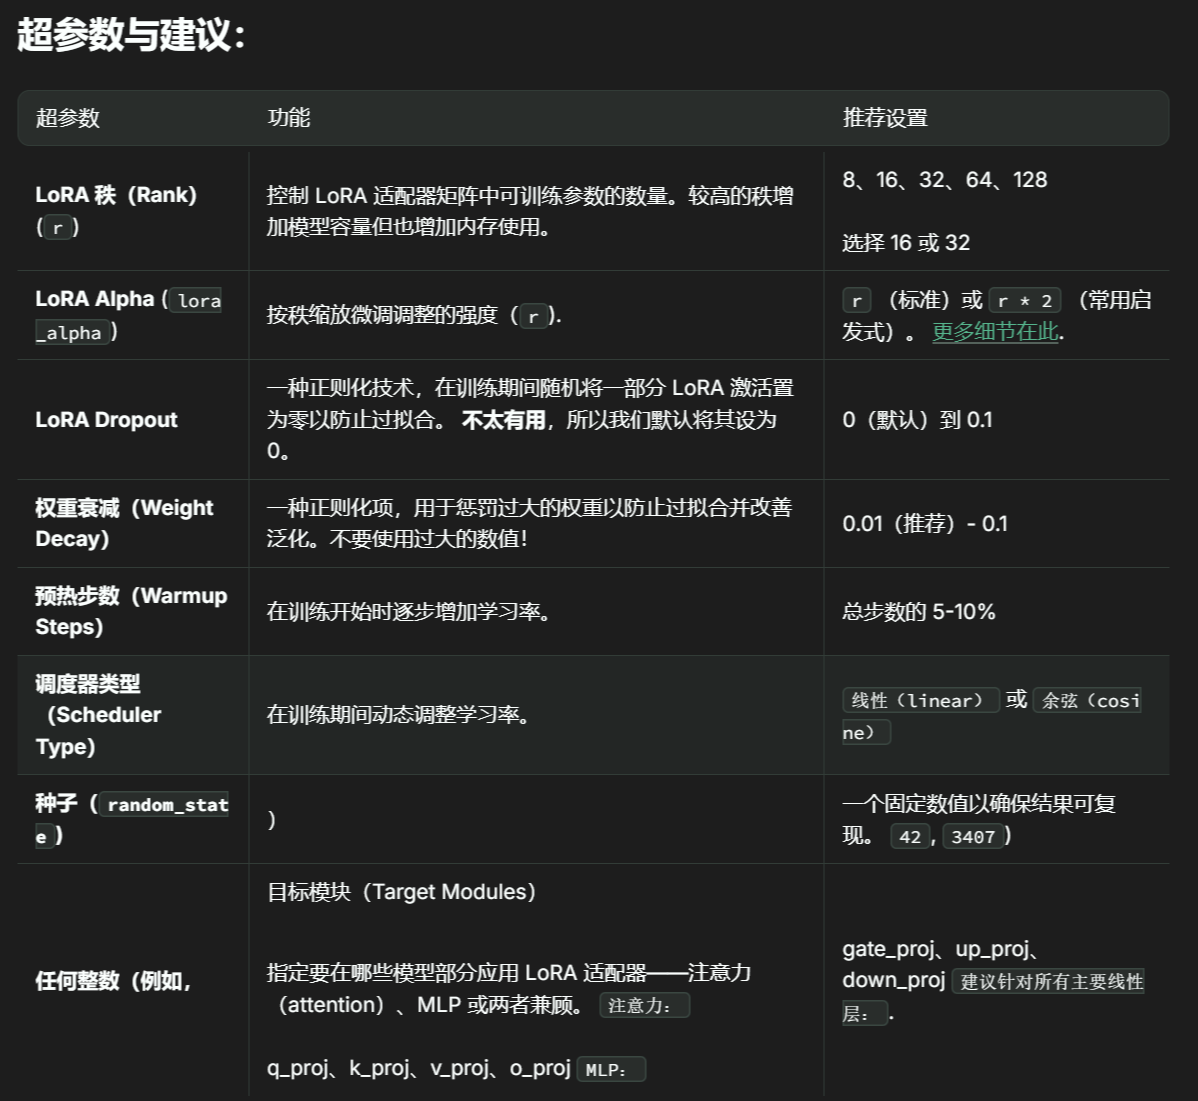

# 🌳 q_proj、k_proj、v_proj、o_proj、gate_proj、up_proj、down_proj